In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

df.shape

(7043, 33)

In [4]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df["Total Charges"] = df["Total Charges"].fillna(
    df["Total Charges"].median()
)

In [29]:
selected_features = [
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Tenure Months',
    'Internet Service',
    'Contract',
    'Payment Method',
    'Monthly Charges'
]

X = df[selected_features]
y = df['Churn Value']


In [30]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", len(categorical_features))
print("Numerical:", len(numerical_features))

Categorical: 7
Numerical: 2


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [33]:
print(categorical_features)
print(numerical_features)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Internet Service', 'Contract', 'Payment Method']
['Tenure Months', 'Monthly Charges']


In [34]:
X_train_processed = preprocessor.fit_transform(X_train)

print(X_train_processed.shape)

(5634, 20)


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

In [36]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [37]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Internet Service',
                                                   'Contract',
                                                   'Payment Method'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [38]:
preds = model.predict(X_test)

probs = model.predict_proba(X_test)[:,1]

In [39]:
print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.7913413768630234
ROC-AUC: 0.8415458937198067


In [40]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
print(cm)

[[909 126]
 [168 206]]


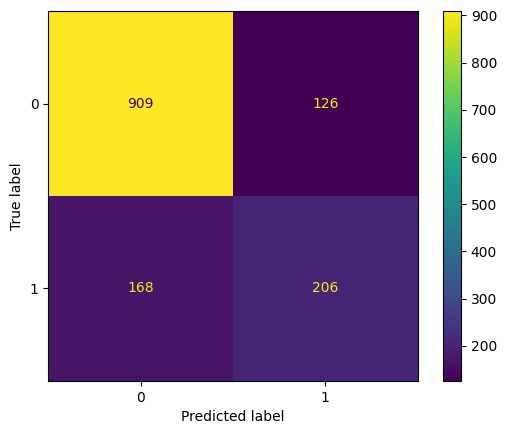

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, preds)

plt.show()

In [43]:
from xgboost import XGBClassifier

/home/msibex/customer-churn-prediction/.venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [44]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [45]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Internet Service',
                                                   'Contract',
                                                   'Payment Method'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [46]:
xgb_preds = xgb_model.predict(X_test)

xgb_probs = xgb_model.predict_proba(X_test)[:,1]

In [47]:
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

Accuracy: 0.7892122072391767
ROC-AUC: 0.835357410421349


## Model Selection

Two models were evaluated:

| Model | Accuracy | ROC-AUC |
|---------|---------|---------|
| Logistic Regression | 0.791 | 0.840 |
| XGBoost | 0.774 | 0.829 |

Logistic Regression achieved superior performance on the test set and was selected as the final model for interpretation and deployment.

In [48]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
8,cat__Dependents_No,0.828595
11,cat__Internet Service_Fiber optic,0.794001
13,cat__Contract_Month-to-month,0.787461
18,cat__Payment Method_Electronic check,0.369565
1,num__Monthly Charges,0.146721
7,cat__Partner_Yes,0.143424
5,cat__Senior Citizen_Yes,0.057545
3,cat__Gender_Male,0.005045
2,cat__Gender_Female,-0.004642
10,cat__Internet Service_DSL,-0.048154


In [49]:
importance.sort_values(
    by="Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
9,cat__Dependents_Yes,-0.828193
0,num__Tenure Months,-0.761990
12,cat__Internet Service_No,-0.745445
15,cat__Contract_Two year,-0.726155
17,cat__Payment Method_Credit card (automatic),-0.164740
6,cat__Partner_No,-0.143022
16,cat__Payment Method_Bank transfer (automatic),-0.120822
19,cat__Payment Method_Mailed check,-0.083601
14,cat__Contract_One year,-0.060904
4,cat__Senior Citizen_No,-0.057143


In [50]:
X_test_processed = model.named_steps["preprocessor"].transform(X_test)

feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [51]:
import shap
explainer = shap.LinearExplainer(
    model.named_steps["classifier"],
    X_test_processed
)

In [52]:
shap_values = explainer(X_test_processed)

In [54]:
X_test_dense = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

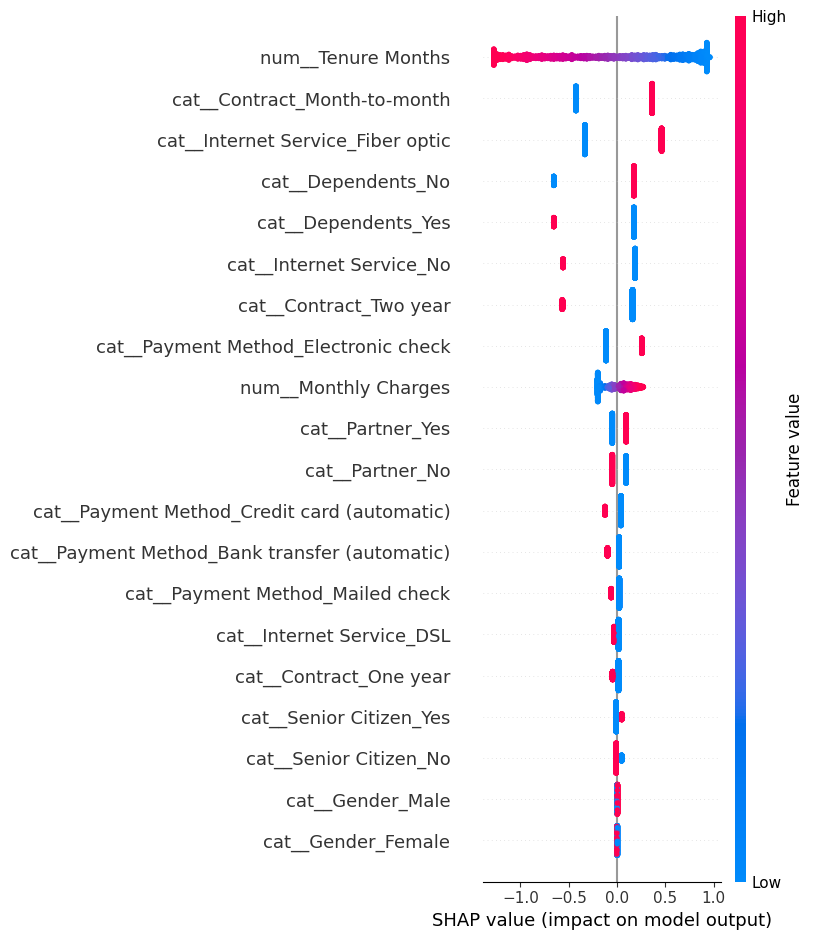

In [55]:
shap.summary_plot(
    shap_values.values,
    X_test_dense
)

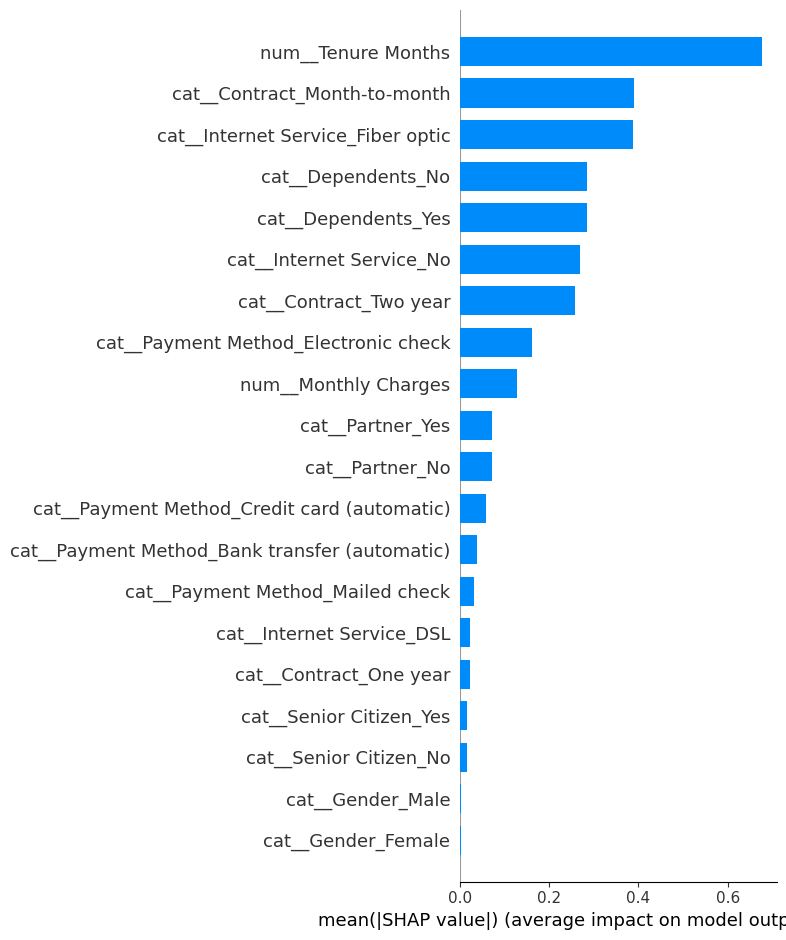

In [56]:
shap.summary_plot(
    shap_values.values,
    X_test_dense,
    plot_type="bar"
)

## Key Findings from SHAP Analysis

The SHAP analysis identified the most influential drivers of customer churn:

1. Customer tenure was the strongest predictor. Long-term customers were significantly less likely to churn.

2. Customers on month-to-month contracts exhibited a substantially higher churn probability compared to customers on annual contracts.

3. Higher monthly charges were associated with increased churn risk.

4. Fiber optic internet service showed a positive contribution to churn predictions.

5. Customers with longer customer lifetime value and longer service history were generally more likely to remain with the company.

These findings are consistent with the exploratory data analysis and provide interpretable business insights that could support customer retention strategies.

In [57]:
import joblib

joblib.dump(model, "../src/churn_model.pkl")

print("Model saved!")

Model saved!


In [58]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

joblib.dump(
    feature_names,
    "../src/feature_names.pkl"
)

['../src/feature_names.pkl']